# 11 — Casos-limite de resolução e auditoria de identidade canônica

Rodada exploratória concentrada nos riscos que impediam um resolver seguro: CNJ/TST discrepante, grupos multi-ID, dispositivos, súmulas e gaps do parser. A prioridade é `wrong_unique = 0`; nenhuma alteração é feita em produção.

## 1. Setup, corpus e reprodução do Notebook 10

`classificacao` e `id_canonico` são carregados somente para auditoria posterior. As consultas experimentais usam exclusivamente o `ParsedCitation`, índices em memória e regras estruturais definidas antes do lookup.

In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import asdict, dataclass
import hashlib
from pathlib import Path
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from bracis_jusbrasil.cases import build_case_index
from bracis_jusbrasil.cases.parser import parse_case_identity
from bracis_jusbrasil.citations import CitationCandidate, CitationParser
from bracis_jusbrasil.database import connect_database, get_database_path

pd.set_option('display.max_colwidth', 110)
DATASET_DIR = next(path for path in (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis')) if path.is_dir())
DB_PATH, GOLDENSET_PATH, TEXT_DIR = DATASET_DIR / 'desafio1_bracis.db', DATASET_DIR / 'goldenset.xlsx', DATASET_DIR / 'txt'
EXPECTED_HASH = 'd759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'
assert hashlib.sha256(DB_PATH.read_bytes()).hexdigest() == EXPECTED_HASH

gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl')
texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
assert len(texts) == 26 and len(gold) == 225
assert all(texts[row.documento_id][int(row.inicio):int(row.fim)] == row.trecho.replace('\\n', '\n') for row in gold.itertuples())
assert gold.classificacao.value_counts().to_dict() == {'real': 96, 'incompleta': 65, 'inventada': 64}

with connect_database(get_database_path(), read_only=True) as connection:
    assert connection.execute('PRAGMA integrity_check').fetchone()[0] == 'ok'
    records = pd.DataFrame([dict(row) for row in connection.execute('SELECT documento_id, id, tribunal, ano, relator, natureza, tipo, texto FROM documentos ORDER BY id').fetchall()])
    schema = pd.DataFrame(connection.execute('PRAGMA table_info(documentos)').fetchall(), columns=['cid', 'column', 'type', 'notnull', 'default', 'pk'])
    index = build_case_index(connection)
records['id'] = records['id'].astype(int)
assert records.natureza.value_counts().to_dict() == {'acordao': 998, 'dispositivo': 13, 'sumula': 5}
assert index.stats == {'records_total': 998, 'case_keys': 912, 'single_id_cases': 833, 'multi_id_cases': 79, 'max_ids_per_case': 4}
print('Dataset e integridade confirmados: 26 textos, 225 citações, 998/13/5 registros canônicos.')

Dataset e integridade confirmados: 26 textos, 225 citações, 998/13/5 registros canônicos.


In [2]:
CNJ = re.compile(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b')
SUMULA = re.compile(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', re.I)
ARTICLE = re.compile(r'\b(?:art(?:igo)?s?[.]?\s*)\d+', re.I)
DIPLOMA = re.compile(r'\b(?:Constituiç[aã]o(?: Federal)?|C[oó]digo|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+|CLT|CPC|CPP|CC|CDC|CPM)\b', re.I)
PROCESS_CLASS = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', re.I)
TRIBUNAL = re.compile(r'\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho|Superior Tribunal Militar)\b', re.I)
YEAR = re.compile(r'\b(?:19\d{2}|20\d{2})\b')
RELATOR = re.compile(r'\b(?:Rel\.?|Relator(?:a)?)\s*(?:Min\.?|Ministra|Ministro|Des\.?)?\s*[A-Z]', re.I)

def family_for_parser(span: str, citation_type: str) -> str:
    if citation_type == 'lei':
        if ARTICLE.search(span) and DIPLOMA.search(span): return 'lei_dispositivo_com_diploma'
        if ARTICLE.search(span): return 'lei_dispositivo_sem_diploma'
        return 'lei_referencia_geral'
    if SUMULA.search(span): return 'sumula_numerada'
    if CNJ.search(span): return 'processo_cnj'
    if PROCESS_CLASS.search(span) and re.search(r'\d', span): return 'processo_ou_recurso_numerado'
    if TRIBUNAL.search(span) and (YEAR.search(span) or RELATOR.search(span)): return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'

@dataclass(frozen=True)
class Probe:
    status: str
    candidate_ids: tuple[int, ...]
    id_canonico: int | None
    strategy: str
    reason: str

def outcome(ids: tuple[int, ...], strategy: str, reason: str) -> Probe:
    if not ids: return Probe('no_match', (), None, strategy, reason)
    if len(ids) == 1: return Probe('resolved_unique', ids, ids[0], strategy, reason)
    return Probe('ambiguous', ids, None, strategy, reason)

case_by_number, case_by_tribunal_number = defaultdict(set), {}
for case in index.cases():
    case_by_number[case.numero_normalizado].update(case.canonical_ids)
    case_by_tribunal_number[(case.tribunal, case.numero_normalizado)] = case
sumula_by_tribunal_number, article_by_number = defaultdict(set), defaultdict(set)
for row in records.itertuples():
    if row.natureza == 'sumula':
        match = re.search(r'S[ÚU]MULA(?:\s+VINCULANTE)?\s+(\d+)', row.texto, re.I)
        if match: sumula_by_tribunal_number[(row.tribunal, match.group(1))].add(row.id)
    elif row.natureza == 'dispositivo':
        match = re.match(r'Art[.]\s*(\d+)', row.texto, re.I)
        if match: article_by_number[match.group(1)].add(row.id)

def baseline_probe(parsed, span: str) -> Probe:
    data = parsed.data
    if parsed.family in {'processo_cnj', 'processo_ou_recurso_numerado'}:
        number = data.get('numero_normalizado')
        if not number: return Probe('insufficient', (), None, 'none', 'missing_process_number')
        if parsed.tribunal:
            case = case_by_tribunal_number.get((parsed.tribunal, number))
            return outcome(tuple(case.canonical_ids) if case else (), 'tribunal_case_number', 'structured_process_number')
        return outcome(tuple(sorted(case_by_number.get(number, ()))), 'case_number_exact', 'structured_process_number')
    if parsed.family == 'sumula_numerada':
        number = data.get('sumula_numero')
        if not number: return Probe('insufficient', (), None, 'none', 'missing_sumula_number')
        if not parsed.tribunal: return Probe('insufficient', (), None, 'sumula_number_only', 'tribunal_required_for_semantic_sufficiency')
        return outcome(tuple(sorted(sumula_by_tribunal_number.get((parsed.tribunal, number), ()))), 'sumula_number_tribunal', 'number_and_tribunal')
    if parsed.family == 'lei_dispositivo_com_diploma':
        article = data.get('artigo')
        if not article: return Probe('insufficient', (), None, 'none', 'missing_legal_identifier')
        return outcome(tuple(sorted(article_by_number.get(article, ()))), 'legal_article_frozen_corpus', 'corpus_lacks_diploma_metadata')
    if parsed.family == 'lei_dispositivo_sem_diploma': return Probe('insufficient', (), None, 'legal_article_only', 'diploma_required')
    if parsed.family == 'jurisprudencia_tribunal_contextual': return Probe('insufficient', (), None, 'contextual_metadata', 'not_primary_identity')
    return Probe('insufficient', (), None, 'none', 'parser_missing_identifier' if re.search(r'\d', span) else 'no_structured_identifier')

def safe_probe(parsed, span: str) -> Probe:
    data = parsed.data
    if parsed.family == 'processo_ou_recurso_numerado':
        number = data.get('numero_normalizado')
        if not number: return Probe('insufficient', (), None, 'none', 'missing_process_number')
        return outcome(tuple(sorted(case_by_number.get(number, ()))), 'case_number_exact', 'explicit_process_number')
    if parsed.family == 'sumula_numerada':
        number = data.get('sumula_numero')
        if not number or not parsed.tribunal: return Probe('insufficient', (), None, 'sumula_number_tribunal', 'number_and_tribunal_required')
        return outcome(tuple(sorted(sumula_by_tribunal_number.get((parsed.tribunal, number), ()))), 'sumula_number_tribunal', 'number_and_tribunal')
    return Probe('insufficient', (), None, 'none', 'outside_safe_strategies')

def evaluate(prober) -> pd.DataFrame:
    parser, rows = CitationParser(), []
    for row in gold.itertuples():
        span = texts[row.documento_id][int(row.inicio):int(row.fim)]
        family = family_for_parser(span, row.tipo)
        parsed = parser.parse(CitationCandidate(0, len(span), span, 'oracle_span', family))
        probe = prober(parsed, span)
        rows.append({'nivel': f'N{row.nivel}', 'documento_id': row.documento_id, 'citacao_id': row.citacao_id, 'inicio': int(row.inicio), 'fim': int(row.fim), 'span': span, 'family': family, 'parsed': parsed, 'parsed_data': dict(parsed.data), 'tribunal': parsed.tribunal, 'gold_class': row.classificacao, 'gold_id': None if pd.isna(row.id_canonico) else int(row.id_canonico), 'status': probe.status, 'candidate_ids': probe.candidate_ids, 'resolved_id': probe.id_canonico, 'strategy': probe.strategy, 'reason': probe.reason})
    frame = pd.DataFrame(rows)
    frame['correct_unique'] = frame.apply(lambda r: r.gold_class == 'real' and r.status == 'resolved_unique' and r.resolved_id == r.gold_id, axis=1)
    frame['wrong_unique_real'] = frame.apply(lambda r: r.gold_class == 'real' and r.status == 'resolved_unique' and r.resolved_id != r.gold_id, axis=1)
    frame['false_real'] = frame.apply(lambda r: r.gold_class != 'real' and r.status == 'resolved_unique', axis=1)
    return frame

baseline, safe = evaluate(baseline_probe), evaluate(safe_probe)
baseline_matrix = pd.crosstab(baseline.gold_class, baseline.status).reindex(index=['real', 'inventada', 'incompleta'], columns=['resolved_unique', 'no_match', 'ambiguous', 'insufficient'], fill_value=0)
assert baseline_matrix.to_dict() == {'resolved_unique': {'real': 75, 'inventada': 1, 'incompleta': 0}, 'no_match': {'real': 2, 'inventada': 51, 'incompleta': 0}, 'ambiguous': {'real': 3, 'inventada': 0, 'incompleta': 0}, 'insufficient': {'real': 16, 'inventada': 12, 'incompleta': 65}}
assert int(baseline.wrong_unique_real.sum() + baseline.false_real.sum()) == 2
print('Baseline do Notebook 10 reproduzida: matriz e dois wrong-unique/false-real confirmados.')
display(baseline_matrix)

Baseline do Notebook 10 reproduzida: matriz e dois wrong-unique/false-real confirmados.


status,resolved_unique,no_match,ambiguous,insufficient
gold_class,,,,
real,75,2,3,16
inventada,1,51,0,12
incompleta,0,0,0,65


## 2. Auditoria CNJ/TST

A inspeção usa busca textual apenas para entender o conflito; ela não participa de nenhuma estratégia de resolução.

In [3]:
cnj_case = baseline.loc[(baseline.documento_id == 'gen_n2_005') & (baseline.citacao_id == 'g6')].iloc[0]
context = texts[cnj_case.documento_id][max(0, cnj_case.inicio - 140):cnj_case.fim + 140]
parsed_cnj = cnj_case.parsed
number = parsed_cnj.data['numero_normalizado']
case = case_by_tribunal_number[(parsed_cnj.tribunal, number)]
ids = set(cnj_case.candidate_ids) | {cnj_case.gold_id}
cnj_records = records.loc[records.id.isin(ids), ['documento_id', 'id', 'tribunal', 'ano', 'relator', 'natureza', 'tipo', 'texto']].copy()
cnj_records['parsed_case_identity'] = cnj_records.apply(lambda row: asdict(parse_case_identity(row.texto, row.tribunal)) if row.natureza == 'acordao' else {}, axis=1)
cnj_records['cited_number_in_text'] = cnj_records.texto.map(lambda text: number in re.sub(r'\D', '', text))
def cited_number_context(text: str) -> str | None:
    match = re.search(r'25823\D{0,5}78\D{0,5}2015\D{0,5}5\D{0,5}24\D{0,5}0091', text)
    return text[max(0, match.start() - 100):match.end() + 100] if match else None
cnj_records['cited_number_context'] = cnj_records.texto.map(cited_number_context)
cnj_records['header'] = cnj_records.texto.str.slice(0, 450)

print('Trecho gold:', repr(cnj_case.span))
print('Contexto:', repr(context))
print('ParsedCitation:', parsed_cnj)
print('Case retornado:', case)
display(cnj_records.drop(columns='texto'))

similar = baseline.loc[(baseline.family == 'processo_cnj') & (baseline.gold_class == 'real') & (baseline.status == 'resolved_unique') & (baseline.resolved_id != baseline.gold_id)]
assert len(similar) == 1
print('Casos CNJ reais com candidato único diferente do gold:', len(similar))
print('Categoria final: gold_inconsistency — o CNJ citado é a identidade estrutural de doc_0729; o registro gold possui outra identidade principal.')
print('Decisão CNJ exact: UNSAFE FOR V1 no contrato atual, apesar de o caso parecer inconsistência isolada de gold/corpus.')

Trecho gold: 'TST-AgARR-25823-78.2015.5.24.\n0091'
Contexto: ' do art 60 da Lei nº 13.467/2017. Ainda que assim não\nfosse, subsiste fundamento autônomo a amparar a pretensão. Confirã-se, a propósito,\no TST-AgARR-25823-78.2015.5.24.\n0091.\n\nIII — DOS PRECEDENTES INVOCADOS\n\nO reclamante foi admitido em 16 de outubro de 2023 para exercer a\nfunção de operador de produção, tendo '
ParsedCitation: ParsedCitation(family='processo_cnj', tipo='jurisprudencia', tribunal_raw='TST', tribunal='TST', tribunal_source='explicit', data=mappingproxy({'numero_raw': '25823-78.2015.5.24.\n0091', 'numero_normalizado': '258237820155240091', 'numero_family': 'cnj'}), provenance=mappingproxy({'numero': 'normalized'}))
Case retornado: Case(tribunal='TST', numero_normalizado='258237820155240091', canonical_ids=(1974934139,), records=(CaseRecord(id_canonico=1974934139, documento_id='doc_0729', tribunal='TST', numero_raw='TST-AIRR-25823-78.2015.5.24.0091', numero_normalizado='258237820155240091', numero_fam

,documento_id,id,tribunal,ano,relator,natureza,tipo,parsed_case_identity,cited_number_in_text,cited_number_context,header
414,doc_0729,1974934139,TST,2017.0,Douglas Alencar Rodrigues,acordao,jurisprudencia,"{'tribunal': 'TST', 'numero_raw': 'TST-AIRR-25823-78.2015.5.24.0091', 'numero_normalizado': '2582378201552...",True,"stos, relatados e discutidos estes autos de Agravo de Instrumento em Recurso de Revista nº TST-AIRR-25823-...",A C Ó R D Ã O (5ª Turma) GMDAR/ASL/JFS AGRAVO DE INSTRUMENTO EM RECURSO DE REVISTA REGIDO PELA LEI 13.015/...
792,doc_0710,2813052232,TST,2024.0,Douglas Alencar Rodrigues,acordao,jurisprudencia,"{'tribunal': 'TST', 'numero_raw': 'TST-Ag-ARR-10132-34.2015.5.03.0018', 'numero_normalizado': '10132342015...",True,"s, inviável a admissibilidade da revista. Agravo de instrumento não provido"". (PROCESSO Nº TST-AIRR-25823-...",A C Ó R D Ã O (5ª Turma) GMDAR/LRRS/JFS I. AGRAVO DA RECLAMANTE. RECURSO DE REVISTA COM AGRAVO. REGIDO PEL...


Casos CNJ reais com candidato único diferente do gold: 1
Categoria final: gold_inconsistency — o CNJ citado é a identidade estrutural de doc_0729; o registro gold possui outra identidade principal.
Decisão CNJ exact: UNSAFE FOR V1 no contrato atual, apesar de o caso parecer inconsistência isolada de gold/corpus.


## 3. Cases multi-ID

Os três casos reais com candidatos múltiplos são auditados com o span e com os metadados disponíveis. Ausência de campo explícito e verificável no span significa `ambiguous`.

In [4]:
multi = baseline.loc[(baseline.gold_class == 'real') & baseline.candidate_ids.map(lambda ids: len(ids) > 1)].copy()
assert len(multi) == 3
multi_view = multi[['documento_id', 'citacao_id', 'family', 'span', 'parsed_data', 'tribunal', 'candidate_ids', 'gold_id']].copy()
candidate_rows = []
for row in multi.itertuples():
    for candidate_id in row.candidate_ids:
        record = records.loc[records.id.eq(candidate_id)].iloc[0]
        identity = asdict(parse_case_identity(record.texto, record.tribunal))
        candidate_rows.append({'citacao_id': row.citacao_id, 'candidate_id': candidate_id, 'is_gold': candidate_id == row.gold_id, 'documento_id': record.documento_id, 'tribunal': record.tribunal, 'ano': record.ano, 'relator': record.relator, 'identity': identity, 'header': record.texto[:350]})
multi_candidates = pd.DataFrame(candidate_rows)
display(multi_view)
display(multi_candidates)
print('Desempate textual seguro: NÃO. Nenhum campo diferenciador está simultaneamente no span e em metadata canônica comparável; todos permanecem ambiguous.')

,documento_id,citacao_id,family,span,parsed_data,tribunal,candidate_ids,gold_id
100,gen_n1_012,g3,processo_cnj,ARR-213-85.2010.5.02.0030,"{'numero_raw': '213-85.2010.5.02.0030', 'numero_normalizado': '2138520105020030', 'numero_family': 'cnj'}",NaN,"(867328396, 1973691658)",8.673284e+08
103,gen_n1_012,g6,processo_cnj,processo nº TST-RR-79500-16.2009.5.15.0016,"{'numero_raw': '79500-16.2009.5.15.0016', 'numero_normalizado': '795001620095150016', 'numero_family': 'cnj'}",TST,"(867273442, 1973130981)",8.672734e+08
197,gen_n2_010,g7,processo_ou_recurso_numerado,AgInt no Recurso Especial nº 1.597.443\n- PR,"{'classe_raw': 'AgInt no Recurso Especial', 'numero_raw': '1.597.443', 'numero_normalizado': '1597443', 'n...",NaN,"(2679428592, 2684973273)",2.684973e+09


,citacao_id,candidate_id,is_gold,documento_id,tribunal,ano,relator,identity,header
0,g3,867328396,True,doc_0670,TST,2016.0,Luiz Philippe Vieira De Mello Filho,"{'tribunal': 'TST', 'numero_raw': 'TST- ARR-213-85.2010.5.02.0030', 'numero_normalizado': '213852010502003...",A C Ó R D Ã O 7ª TURMA VMF/cfr/pcp/rs RECURSO DE REVISTA DA UNIÃO - RECURSO INTERPOSTO SOB A ÉGIDE DO CPC/...
1,g3,1973691658,False,doc_0662,TST,2016.0,Luiz Philippe Vieira De Mello Filho,"{'tribunal': 'TST', 'numero_raw': 'TST-ARR-213-85.2010.5.02.0030', 'numero_normalizado': '2138520105020030...",A C Ó R D Ã O 7ª TURMA VMF/cfr/pcp/rs RECURSO DE REVISTA DA UNIÃO – RECURSO INTERPOSTO SOB A ÉGIDE DO CPC/...
2,g6,867273442,True,doc_0640,TST,2016.0,Luiz Philippe Vieira De Mello Filho,"{'tribunal': 'TST', 'numero_raw': 'TST-RR-79500-16.2009.5.15.0016', 'numero_normalizado': '795001620095150...",A C Ó R D Ã O 7ª TURMA VMF/cfr/pcp/rs RECURSO DE REVISTA - RECURSO INTERPOSTO SOB A ÉGIDE DO CPC/73 E ANTE...
3,g6,1973130981,False,doc_0657,TST,2016.0,Luiz Philippe Vieira De Mello Filho,"{'tribunal': 'TST', 'numero_raw': 'TST-RR-79500-16.2009.5.15.0016', 'numero_normalizado': '795001620095150...",A C Ó R D Ã O 7ª TURMA VMF/cfr/pcp/rs RECURSO DE REVISTA – RECURSO INTERPOSTO SOB A ÉGIDE DO CPC/73 E ANTE...
4,g7,2679428592,False,doc_0289,STJ,2019.0,Nancy Andrighi,"{'tribunal': 'STJ', 'numero_raw': '1597443', 'numero_normalizado': '1597443', 'numero_family': 'cnj', 'par...",Superior Tribunal de Justiça AgInt nosEMBARGOS DE DIVERGÊNCIA EM RESP Nº 1597443 - PR (2016/0115164-6) REL...
5,g7,2684973273,True,doc_0212,STJ,2018.0,Napoleão Nunes Maia Filho,"{'tribunal': 'STJ', 'numero_raw': '1.597.443', 'numero_normalizado': '1597443', 'numero_family': 'cnj', 'p...",AgInt no RECURSO ESPECIAL Nº 1.597.443 - PR (2016/0115164-6) RELATOR : MINISTRO NAPOLEÃO NUNES MAIA FILHO ...


Desempate textual seguro: NÃO. Nenhum campo diferenciador está simultaneamente no span e em metadata canônica comparável; todos permanecem ambiguous.


## 4. Identidade legal

A tabela `documentos` não possui coluna de diploma. A extração abaixo examina somente a primeira linha de cada dispositivo para evitar confundir remissões internas ao texto legal com a identidade do próprio registro.

In [5]:
devices = records.loc[records.natureza.eq('dispositivo')].copy()
def device_header_identity(text: str) -> tuple[str | None, str | None]:
    first_line = text.splitlines()[0]
    article = re.search(r'Art[.]\s*(\d+)', first_line, re.I)
    diploma = re.search(r'(Constituiç[aã]o[^,.;]*|C[oó]digo[^,.;]*|Lei(?: Complementar)?\s+n?[ºo.]?\s*\d+[./]?[0-9]*)', first_line, re.I)
    return (article.group(1) if article else None, diploma.group(1) if diploma else None)
devices[['artigo', 'diploma_aparente_no_cabecalho']] = devices.texto.map(device_header_identity).apply(pd.Series)
devices['header'] = devices.texto.map(lambda text: text.splitlines()[0])
display(schema[['column', 'type', 'pk']])
display(devices[['documento_id', 'id', 'artigo', 'diploma_aparente_no_cabecalho', 'header']])
print('Diploma estruturado em coluna do banco: NÃO; menções lexicais no cabeçalho:', int(devices['diploma_aparente_no_cabecalho'].notna().sum()))

legal_real = baseline.loc[(baseline.family == 'lei_dispositivo_com_diploma') & (baseline.gold_class == 'real')].copy()
legal_real['record_article'] = legal_real.gold_id.map(devices.set_index('id')['artigo'])
legal_real['record_diploma'] = legal_real.gold_id.map(devices.set_index('id')['diploma_aparente_no_cabecalho'])
display(legal_real[['citacao_id', 'span', 'parsed_data', 'gold_id', 'record_article', 'record_diploma']])
wrong_legal = baseline.loc[(baseline.family == 'lei_dispositivo_com_diploma') & baseline.false_real]
display(wrong_legal[['documento_id', 'citacao_id', 'span', 'candidate_ids', 'strategy', 'reason']])
print('Combinações verificáveis: somente artigo. Artigo + diploma/law_number não é verificável no corpus atual.')
print('Legal strategy: UNSAFE. Artigo sozinho é proibido para resolved_unique; sem diploma verificável, retornar insufficient.')

,column,type,pk
0,documento_id,TEXT,1
1,id,INTEGER,0
2,tribunal,TEXT,0
3,ano,INTEGER,0
4,relator,TEXT,0
5,natureza,TEXT,0
6,tipo,TEXT,0
7,texto,TEXT,0
8,texto_len,INTEGER,0


,documento_id,id,artigo,diploma_aparente_no_cabecalho,header
0,10577194,10577194,276,NaN,"Art. 276. As decisões dos Tribunais Regionais são terminativas, salvo os casos seguintes em que cabe recur..."
1,10590194,10590194,290,NaN,"Art. 290. Receber, preparar, produzir, vender, fornecer, ainda que gratuitamente, ter em depósito, transpo..."
2,10606184,10606184,14,NaN,"Art. 14. O fornecedor de serviços responde, independentemente da existência de culpa, pela reparação dos d..."
3,10626510,10626510,93,NaN,"Art. 93. Lei complementar, de iniciativa do Supremo Tribunal Federal, disporá sobre o Estatuto da Magistra..."
4,10637358,10637358,896,Lei nº 9.756,Art. 896 - Cabe Recurso de Revista para Turma do Tribunal Superior do Trabalho das decisões proferidas em ...
5,10641213,10641213,7,NaN,"Art. 7º São direitos dos trabalhadores urbanos e rurais, além de outros que visem à melhoria de sua condiç..."
6,10641516,10641516,5,NaN,"Art. 5º Todos são iguais perante a lei, sem distinção de qualquer natureza, garantindo-se aos brasileiros ..."
7,10647746,10647746,818,Lei nº 13.467,"Art. 818. O ônus da prova incumbe: (Redação dada pela Lei nº 13.467, de 2017)"
8,10652044,10652044,312,Lei nº 13.964,"Art. 312. A prisão preventiva poderá ser decretada como garantia da ordem pública, da ordem econômica, por..."
9,10710324,10710324,477,Lei nº 13.467,"Art. 477. Na extinção do contrato de trabalho, o empregador deverá proceder à anotação na Carteira de Trab..."


Diploma estruturado em coluna do banco: NÃO; menções lexicais no cabeçalho: 4


,citacao_id,span,parsed_data,gold_id,record_article,record_diploma
27,g9,"art. 373, I, do CPC","{'artigo': '373', 'diploma_raw': 'CPC', 'diploma_normalizado': 'CPC'}",28893055.0,373,NaN
33,g6,art.\n290 do Código Penal Militar,"{'artigo': '290', 'diploma_raw': 'Código Penal', 'diploma_normalizado': 'CÓDIGO PENAL'}",10590194.0,290,NaN
52,g1,"art. 93, IX, da Constituição da República","{'artigo': '93', 'diploma_raw': 'Constituição', 'diploma_normalizado': 'CONSTITUIÇÃO'}",10626510.0,93,NaN
66,g6,art. 818 da CLT,"{'artigo': '818', 'diploma_raw': 'CLT', 'diploma_normalizado': 'CLT'}",10647746.0,818,Lei nº 13.467
94,g4,"art. 5º, LV, da Constituição Federal","{'artigo': '5', 'diploma_raw': 'Constituição Federal', 'diploma_normalizado': 'CONSTITUIÇÃO FEDERAL'}",10641516.0,5,NaN
99,g2,"art. 896, § 1º-A, da CLT","{'artigo': '896', 'paragrafo': '1', 'diploma_raw': 'CLT', 'diploma_normalizado': 'CLT'}",10637358.0,896,Lei nº 9.756
111,g4,"art. 1º, I, 'g', da Lei Complementar nº 64/1990","{'artigo': '1', 'diploma_raw': 'Lei Complementar nº 64/1990', 'diploma_normalizado': 'LEI COMPLEMENTAR Nº ...",11304039.0,1,NaN
129,g6,"artigo 93, IX, da Constituição\nda República","{'artigo': '93', 'diploma_raw': 'Constituição', 'diploma_normalizado': 'CONSTITUIÇÃO'}",10626510.0,93,NaN
155,g9,"artigo 7º, XXIX, da Constituição Fedcral","{'artigo': '7', 'diploma_raw': 'Constituição', 'diploma_normalizado': 'CONSTITUIÇÃO'}",10641213.0,7,NaN
157,g2,art 276 do Código Eleitoral,"{'artigo': '276', 'diploma_raw': 'Código', 'diploma_normalizado': 'CÓDIGO'}",10577194.0,276,NaN


,documento_id,citacao_id,span,candidate_ids,strategy,reason
166,gen_n2_007,g2,art 290 da Constituição\nFederal,"(10590194,)",legal_article_frozen_corpus,corpus_lacks_diploma_metadata


Combinações verificáveis: somente artigo. Artigo + diploma/law_number não é verificável no corpus atual.
Legal strategy: UNSAFE. Artigo sozinho é proibido para resolved_unique; sem diploma verificável, retornar insufficient.


## 5. Súmulas e gaps do parser

Número + tribunal é testado somente quando ambos estão no `ParsedCitation` e o número também aparece de forma estruturada no registro.

,documento_id,id,tribunal,numero_no_texto,header
198,1289710642,1289710642,STJ,83,"DIREITO PROCESSUAL CIVIL - RECURSO ESPECIAL\nNão se conhece do recurso especial pela divergência, quando a..."
199,1289710776,1289710776,STJ,211,"DIREITO PROCESSUAL CIVIL - RECURSO ESPECIAL\nInadmissível recurso especial quanto à questão que, a despeit..."
200,1289711022,1289711022,STJ,443,DIREITO PENAL - APLICAÇÃO DA PENA\nO aumento na terceira fase de aplicação da pena no crime de roubo circu...
201,1289712966,1289712966,STF,NaN,"PROCESSUAL CIVIL\nViola a cláusula de reserva de plenário ( CF, artigo 97) a decisão de órgão fracionário ..."
213,1431369957,1431369957,TST,NaN,CONTRATO DE PRESTAÇÃO DE SERVIÇOS. LEGALIDADE.\nI - A contratação de trabalhadores por empresa interposta ...


,gold_class,resolved,no_match,insufficient
0,inventada,0,4,2
1,real,2,1,1


Sumula strategy: PARTIAL — tribunal+número é seguro quando a chave existe; duas referências reais continuam bloqueadas por ausência de tribunal parseado ou número estruturado no corpus.


,gap_type,count,documents,N1,N2,families
0,jurisprudence_general_identifier_present,13,8,2,11,jurisprudencia_referencia_geral
1,process_number_present,1,1,1,0,processo_ou_recurso_numerado


,documento_id,citacao_id,nivel,family,span,parsed_data,gap_type
71,gen_n1_009,g1,N1,jurisprudencia_referencia_geral,Embargos de Declaração no Recurso em Mandado de Segurança\nnº 67.101/RJ,{},jurisprudence_general_identifier_present
82,gen_n1_010,g2,N1,jurisprudencia_referencia_geral,RHC nº\n88.033/RS,{},jurisprudence_general_identifier_present
98,gen_n1_012,g1,N1,processo_ou_recurso_numerado,ED-E-ED-RR-65-63.2010.5.01.0075,{'classe_raw': 'RR'},process_number_present
125,gen_n2_002,g2,N2,jurisprudencia_referencia_geral,5úmula 211 do STJ,{},jurisprudence_general_identifier_present
130,gen_n2_002,g7,N2,jurisprudencia_referencia_geral,Rec. Esp. No 1.880.529\n- SP,{},jurisprudence_general_identifier_present
143,gen_n2_004,g5,N2,jurisprudencia_referencia_geral,REspe. n° 0600216-46.2020-\n.6.14.0022,{},jurisprudence_general_identifier_present
159,gen_n2_006,g4,N2,jurisprudencia_referencia_geral,ED no AgR-REspe No 0600316-4920206160182,{},jurisprudence_general_identifier_present
165,gen_n2_007,g1,N2,jurisprudencia_referencia_geral,Ag. Int. No 7001184-1520197000000,{},jurisprudence_general_identifier_present
170,gen_n2_007,g6,N2,jurisprudencia_referencia_geral,APL\n 7000761-84 2021 7 00 0000/BA,{},jurisprudence_general_identifier_present
172,gen_n2_007,g8,N2,jurisprudencia_referencia_geral,RSE n. 7000171-3920237000000 (DF),{},jurisprudence_general_identifier_present


Parser V2 necessário? NÃO. Há 13 identificadores heterogêneos em família geral e um único composto trabalhista; não há mecanismo pequeno, geral e de baixo risco para promover agora.


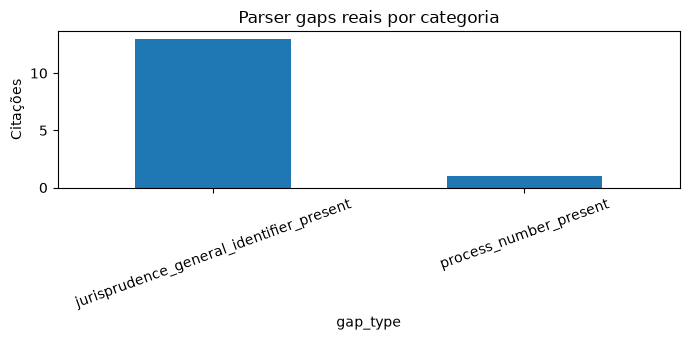

In [6]:
sumulas = records.loc[records.natureza.eq('sumula')].copy()
sumulas['numero_no_texto'] = sumulas.texto.map(lambda text: (match.group(1) if (match := re.search(r'S[ÚU]MULA(?:\s+VINCULANTE)?\s+(\d+)', text, re.I)) else None))
sumulas['header'] = sumulas.texto.str.slice(0, 260)
display(sumulas[['documento_id', 'id', 'tribunal', 'numero_no_texto', 'header']])
sumula_result = (baseline.loc[baseline.family.eq('sumula_numerada')].groupby('gold_class', as_index=False)
                 .agg(resolved=('status', lambda value: (value == 'resolved_unique').sum()), no_match=('status', lambda value: (value == 'no_match').sum()), insufficient=('status', lambda value: (value == 'insufficient').sum())))
display(sumula_result)
print('Sumula strategy: PARTIAL — tribunal+número é seguro quando a chave existe; duas referências reais continuam bloqueadas por ausência de tribunal parseado ou número estruturado no corpus.')

gaps = baseline.loc[(baseline.gold_class == 'real') & (((baseline.family == 'jurisprudencia_referencia_geral') & baseline.span.str.contains(r'\d')) | ((baseline.family == 'processo_ou_recurso_numerado') & ~baseline.parsed_data.map(lambda data: 'numero_normalizado' in data)))].copy()
def gap_type(row) -> str:
    return 'process_number_present' if row.family == 'processo_ou_recurso_numerado' else 'jurisprudence_general_identifier_present'
gaps['gap_type'] = gaps.apply(gap_type, axis=1)
assert len(gaps) == 14
gap_summary = (gaps.groupby('gap_type', as_index=False)
               .agg(count=('citacao_id', 'size'), documents=('documento_id', 'nunique'), N1=('nivel', lambda value: (value == 'N1').sum()), N2=('nivel', lambda value: (value == 'N2').sum()), families=('family', lambda value: ', '.join(sorted(set(value))))))
display(gap_summary)
display(gaps[['documento_id', 'citacao_id', 'nivel', 'family', 'span', 'parsed_data', 'gap_type']])
print('Parser V2 necessário? NÃO. Há 13 identificadores heterogêneos em família geral e um único composto trabalhista; não há mecanismo pequeno, geral e de baixo risco para promover agora.')

fig, ax = plt.subplots(figsize=(7, 3.5))
gap_summary.plot.bar(x='gap_type', y='count', ax=ax, legend=False)
ax.set_title('Parser gaps reais por categoria')
ax.set_ylabel('Citações')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 6. SAFE_STRATEGIES e reavaliação

Somente duas estratégias entram: número explícito para `processo_ou_recurso_numerado` e número+tribunal para súmulas. CNJ e legal ficam deliberadamente fora.

,strategy,families,support,correct unique,wrong unique,risk
0,case_number_exact,processo_ou_recurso_numerado,85,39,0,LOW
1,sumula_number_tribunal,sumula_numerada,7,2,0,LOW


status,resolved_unique,no_match,ambiguous,insufficient
gold_class,,,,
real,41,2,1,52
inventada,0,36,0,28
incompleta,0,0,0,65


,métrica,Notebook 10,SAFE_STRATEGIES
0,correct real unique,74,41
1,wrong unique real,1,0
2,false-real inventada,1,0
3,false-real incompleta,0,0
4,invented no-match,51,36
5,incomplete safe,65,65


Safe real coverage: 41/96 (42.7%); inventadas no-match: 36/64 (56.2%); oracle classification segura: 63.1%.
Erros críticos (wrong-real / false invented / false incomplete): 0 0 0


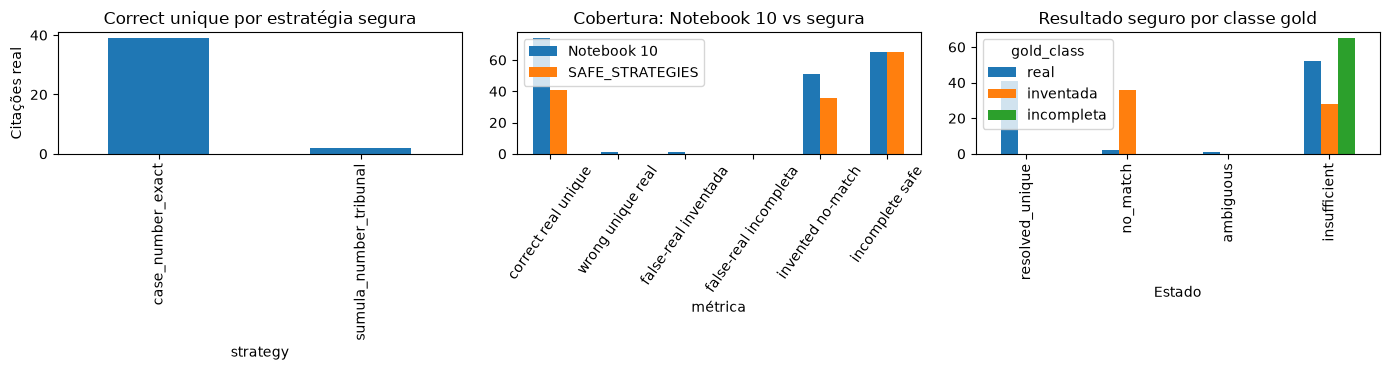

In [7]:
safe_matrix = pd.crosstab(safe.gold_class, safe.status).reindex(index=['real', 'inventada', 'incompleta'], columns=['resolved_unique', 'no_match', 'ambiguous', 'insufficient'], fill_value=0)
assert safe_matrix.to_dict() == {'resolved_unique': {'real': 41, 'inventada': 0, 'incompleta': 0}, 'no_match': {'real': 2, 'inventada': 36, 'incompleta': 0}, 'ambiguous': {'real': 1, 'inventada': 0, 'incompleta': 0}, 'insufficient': {'real': 52, 'inventada': 28, 'incompleta': 65}}
wrong_real = int(safe.wrong_unique_real.sum())
false_invented = int(safe.loc[safe.gold_class.eq('inventada'), 'false_real'].sum())
false_incomplete = int(safe.loc[safe.gold_class.eq('incompleta'), 'false_real'].sum())
assert (wrong_real, false_invented, false_incomplete) == (0, 0, 0)

safe_strategies = pd.DataFrame([
    ('case_number_exact', 'processo_ou_recurso_numerado', 85, 39, 0, 'LOW'),
    ('sumula_number_tribunal', 'sumula_numerada', 7, 2, 0, 'LOW'),
], columns=['strategy', 'families', 'support', 'correct unique', 'wrong unique', 'risk'])
comparison = pd.DataFrame([
    ('correct real unique', 74, 41), ('wrong unique real', 1, wrong_real),
    ('false-real inventada', 1, false_invented), ('false-real incompleta', 0, false_incomplete),
    ('invented no-match', 51, int(((safe.gold_class == 'inventada') & (safe.status == 'no_match')).sum())),
    ('incomplete safe', 65, int(((safe.gold_class == 'incompleta') & safe.status.isin(['ambiguous', 'insufficient'])).sum())),
], columns=['métrica', 'Notebook 10', 'SAFE_STRATEGIES'])
classification = safe.status.map({'resolved_unique': 'real', 'no_match': 'inventada', 'ambiguous': 'incompleta', 'insufficient': 'incompleta'})
accuracy = (classification == safe.gold_class).mean()

display(safe_strategies)
display(safe_matrix)
display(comparison)
print(f'Safe real coverage: 41/96 ({41/96:.1%}); inventadas no-match: 36/64 ({36/64:.1%}); oracle classification segura: {accuracy:.1%}.')
print('Erros críticos (wrong-real / false invented / false incomplete):', wrong_real, false_invented, false_incomplete)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
safe_strategies.plot.bar(x='strategy', y='correct unique', ax=axes[0], legend=False)
axes[0].set_title('Correct unique por estratégia segura')
axes[0].set_ylabel('Citações real')
comparison.set_index('métrica')[['Notebook 10', 'SAFE_STRATEGIES']].plot.bar(ax=axes[1])
axes[1].set_title('Cobertura: Notebook 10 vs segura')
axes[1].tick_params(axis='x', rotation=55)
safe_matrix.T.plot.bar(ax=axes[2])
axes[2].set_title('Resultado seguro por classe gold')
axes[2].set_xlabel('Estado')
plt.tight_layout()
plt.show()

## 7. Determinismo, contrato e decisão

A recomendação limita-se às duas estratégias que atingiram zero IDs errados e zero false-real no gold atual.

In [8]:
snapshots, started = [], time.perf_counter()
for _ in range(3):
    run = evaluate(safe_probe).assign(resolved_id=lambda frame: frame.resolved_id.fillna(-1).astype(int))
    snapshots.append(tuple(run[['status', 'candidate_ids', 'resolved_id', 'strategy', 'reason']].itertuples(index=False, name=None)))
elapsed_ms = (time.perf_counter() - started) * 1000
assert snapshots[0] == snapshots[1] == snapshots[2]
print(f'Três execuções idênticas; {elapsed_ms:.1f} ms para 3 × 225 citações.')
print('ResolutionResult(status, id_canonico, candidate_ids, strategy, reason, record_type)')
print('Invariantes: resolved => um ID; no_match => query suficiente e (); ambiguous => >1 IDs; insufficient => ausência de lookup não decide classe.')
print('Arquitetura futura: CitationResolver único com dispatch interno resolve_case/resolve_sumula/resolve_legal; V1 implementaria somente CaseIndex e mapping de súmula tribunal+número.')

Três execuções idênticas; 53.1 ms para 3 × 225 citações.
ResolutionResult(status, id_canonico, candidate_ids, strategy, reason, record_type)
Invariantes: resolved => um ID; no_match => query suficiente e (); ambiguous => >1 IDs; insufficient => ausência de lookup não decide classe.
Arquitetura futura: CitationResolver único com dispatch interno resolve_case/resolve_sumula/resolve_legal; V1 implementaria somente CaseIndex e mapping de súmula tribunal+número.


## 8. Findings e decisão

- O conflito CNJ/TST é isolado e a evidência aponta para `gold_inconsistency`, mas `cnj_exact` permanece fora da V1 enquanto o contrato de avaliação exigir o ID divergente.
- Os três multi-ID permanecem corretamente `ambiguous`: nenhum desempate geral foi encontrado no span.
- Dispositivos não expõem diploma verificável no schema; artigo isolado é inseguro.
- Súmula por tribunal+número e processo/recurso por número explícito atingem zero erros críticos no gold atual.
- Os 14 parser gaps não justificam Parser V2: são 13 padrões heterogêneos de referência geral e um caso composto isolado.

**Decisão: A) implementar `CitationResolver` V1 com `SAFE_STRATEGIES`**, limitado a `case_number_exact` para `processo_ou_recurso_numerado` e `sumula_number_tribunal`. CNJ, dispositivos legais, multi-ID e famílias sem identidade continuam retornando `ambiguous` ou `insufficient`. Nenhuma implementação é feita neste notebook.